# Look at Mackenzie River runoff climatology used in model

In [1]:
## import required packages
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

## import ECCO utils
import sys
sys.path.append('/Users/mzahn/github_others/ECCOv4-py')
import ecco_v4_py as ecco

[Fekete et al. (2002) paper](https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/1999GB001254) <br>
[Link to datasets](https://www.compositerunoff.sr.unh.edu/html/Data/index.html)

In [4]:
# define directory for runoff file
fdir = '/Users/mzahn/data/SASSIE/model/input/'
fname = 'runoff1p2472-360x180x12.bin'
num_cols = 180
num_rows = 360

In [6]:
# open .bin file
runoff_bin = ecco.load_binary_array(fdir, fname, ni=num_rows, nj=num_cols, nk=12, nl=1, skip=0,\
                                    filetype = '>f', less_output = False )

load_binary_array: loading file /Users/mzahn/data/SASSIE/model/input/runoff1p2472-360x180x12.bin
load_binary_array: data array shape  (12, 180, 360)
load_binary_array: data array type  >f4


In [8]:
# look at shape
runoff_bin.shape

(12, 180, 360)

In [10]:
12*180*360 # correct shape of data

777600

In [12]:
np.max(runoff_bin)

743.208

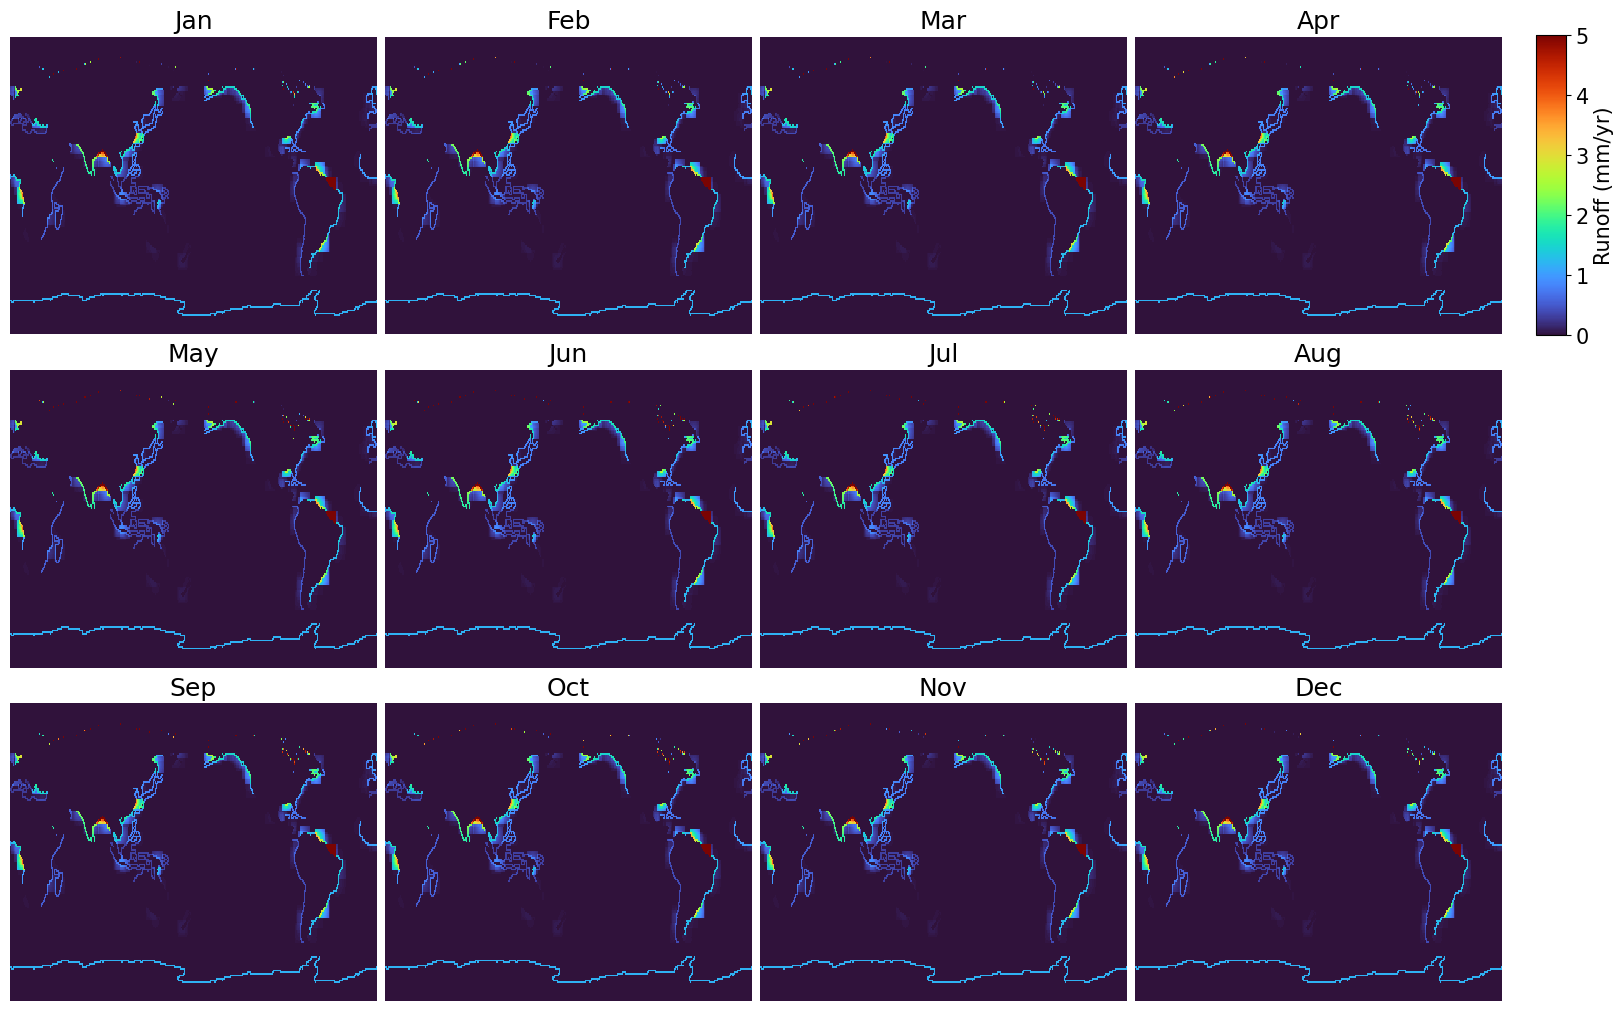

In [14]:
plt.rcParams['font.size'] = 15
fig, axes = plt.subplots(3, 4, figsize=(15, 10), constrained_layout=True)
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Define a colormap range
vmin, vmax = 0, 5

for i, ax in enumerate(axes.flat):
    im = ax.pcolormesh(runoff_bin[i], vmin=vmin, vmax=vmax, cmap='turbo')
    ax.set_title(months[i])
    ax.axis("off")  # Remove axis ticks

# Add a single colorbar to the right of all subplots
cbar_ax = fig.add_axes([1.02, 0.67, 0.02, 0.3])  # Position: [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax, label="Runoff (mm/yr)")

plt.show()

### Zoom into Mackenzie River discharge

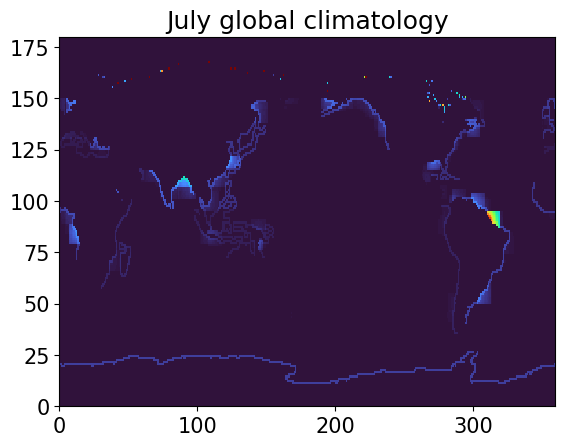

In [17]:
# first plot entire globe
plt.pcolormesh(runoff_bin[6], vmin=0, vmax=20, cmap='turbo');
plt.title('July global climatology');

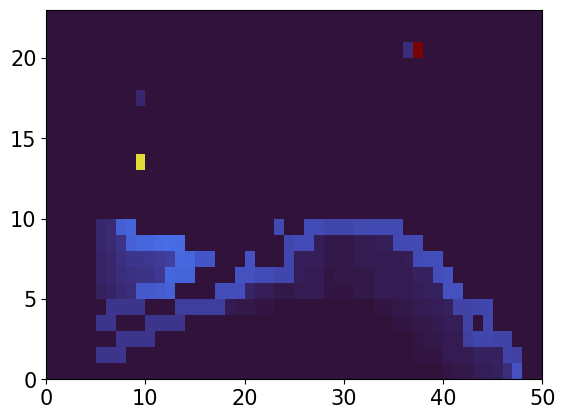

In [19]:
# zoom into Alaska
plt.pcolormesh(runoff_bin[0][140:163,185:235], vmin=0, vmax=20, cmap='turbo');

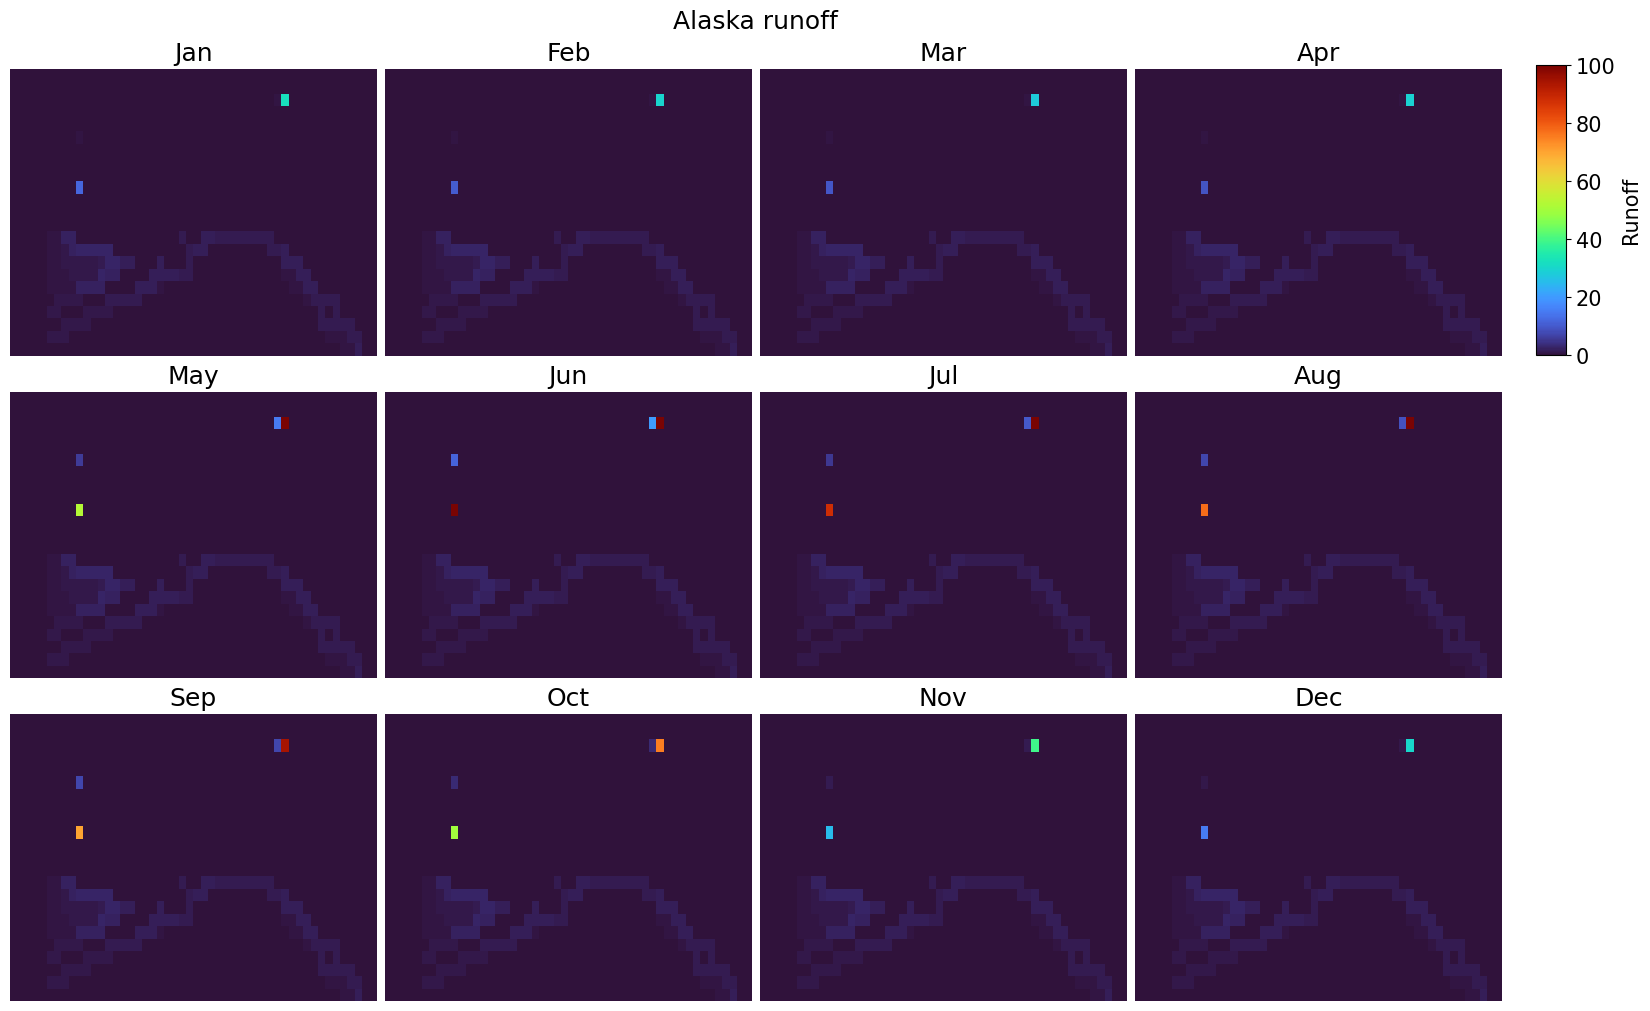

In [21]:
plt.rcParams['font.size'] = 15
fig, axes = plt.subplots(3, 4, figsize=(15, 10), constrained_layout=True)
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Define a colormap range
vmin, vmax = 0, 100

for i, ax in enumerate(axes.flat):
    im = ax.pcolormesh(runoff_bin[i][140:163,185:235], vmin=vmin, vmax=vmax, cmap='turbo')
    ax.set_title(months[i])
    ax.axis("off")  # Remove axis ticks

plt.suptitle('Alaska runoff')

# Add a single colorbar to the right of all subplots
cbar_ax = fig.add_axes([1.02, 0.65, 0.02, 0.29])  # Position: [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax, label="Runoff")

plt.show()

## Make a dataset and isolate Mackenzie River runoff

In [38]:
runoff_ds = xr.DataArray(
    data=runoff_bin,
    dims=["month", "j", "i"],
    coords=dict(
        month=np.arange(1,13,1),
        j=np.arange(0,180,1),
        i=np.arange(0,360,1),
    ),
    attrs=dict(
        description="Runoff",
        units="m/s",
    ),
)

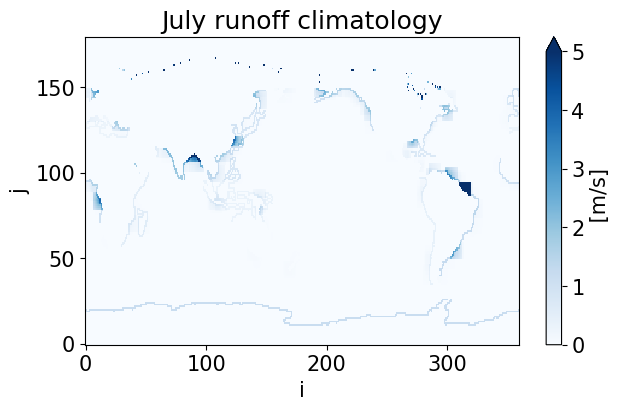

In [40]:
runoff_ds.isel(month=6).plot(vmin=0,vmax=5,cmap='Blues',figsize=[7,4]);
plt.title('July runoff climatology');

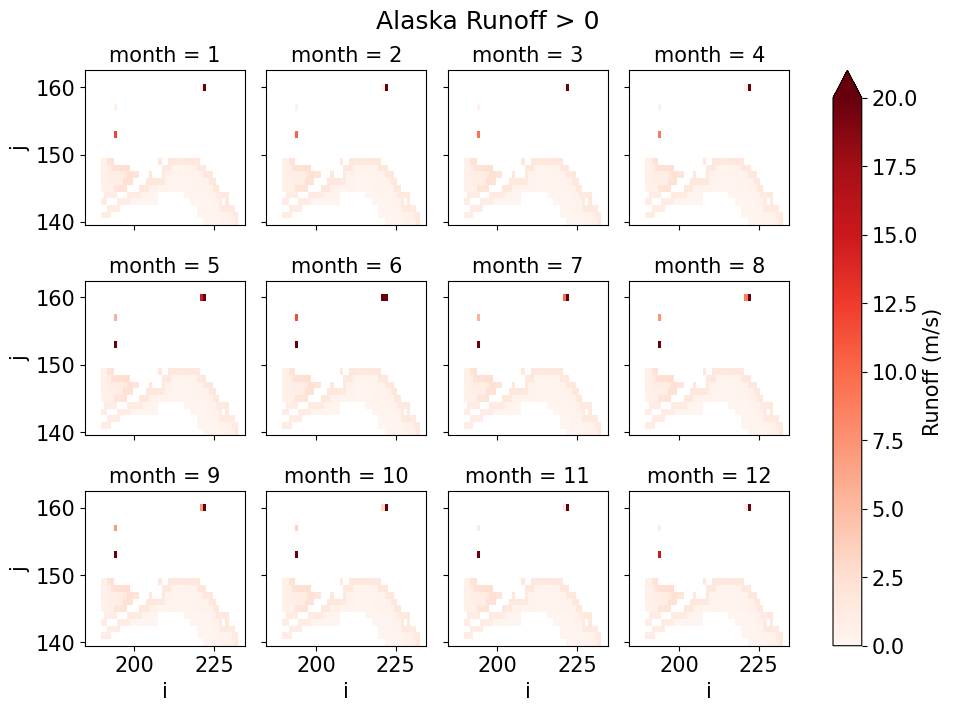

In [42]:
plt.rcParams['font.size'] = 15
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Select the subset region (i=140:163, j=185:235)
# runoff_subset = runoff_ds.where(runoff_ds>0).isel(i=slice(220,225),j=slice(155,163))
runoff_subset = runoff_ds.where(runoff_ds>0).isel(i=slice(185,235),j=slice(140,163))

# Plot using xarray's built-in facet plotting
runoff_subset.plot(col="month", col_wrap=4, cmap="Reds", 
                          vmin=0, vmax=20, figsize=(10, 7),
                          cbar_kwargs={"label": r"Runoff (m/s)"})

plt.suptitle('Alaska Runoff > 0', fontsize=18, y=1.02)
plt.show()

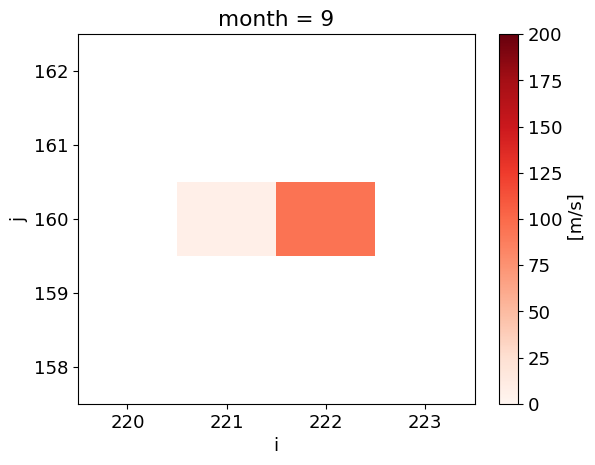

In [313]:
runoff_ds.where(runoff_ds>0).isel(month=8,i=slice(220,224),j=slice(158,163)).plot(vmin=0,vmax=200, cmap="Reds");

In [48]:
runoff_total_mpers = runoff_ds.isel(i=slice(221,223),j=160).sum(dim='i')

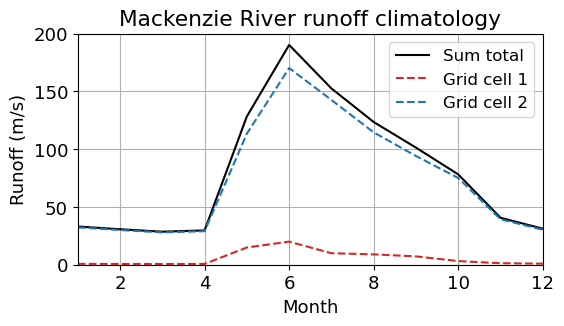

In [311]:
plt.rcParams['font.size'] = 13
# select two grid cells dedicated to Mackenzie River outflow
runoff_total_mpers.plot(color='k',figsize=[6,3],label='Sum total'); # we can sum them because they are the same area grid cells
runoff_ds.isel(i=221,j=160).plot(color='tab:red',linestyle='dashed',label='Grid cell 1')
runoff_ds.isel(i=222,j=160).plot(color='tab:blue',linestyle='dashed',label='Grid cell 2')
plt.title('Mackenzie River runoff climatology')
plt.legend(fontsize=12)
plt.ylim(0,200)
plt.xlim(1,12)
plt.grid()
plt.ylabel(r'Runoff (m/s)')
plt.xlabel('Month');

### Convert to m3/s

In [246]:
R = 6371  # radius of Earth in km
latitudes = np.linspace(-90, 90, 180)
longitudes = np.concatenate([np.linspace(0, 180, 181), np.linspace(-179, -1, 179)])
# create a meshgrid for latitudes and longitudes
lat_grid, lon_grid = np.meshgrid(latitudes, longitudes)

# calculate the distance for each degree of latitude (constant for each degree of latitude)
lat_distance = (2 * np.pi * 6378) / 360 * 1000 # total circumference (2*pi*R) divided by 360 - in m
print(lat_distance)

111317.09969219835


In [248]:
# calculate distance for each degree of longitude, varies with latitude
lon_distance = lat_distance * np.cos(np.deg2rad(lat_grid))  # in m

# Calculate the area for each grid cell
cell_area = lat_distance * lon_distance  # m^2

In [250]:
cell_area_da = xr.DataArray(
    cell_area,
    coords=[("longitude", longitudes), ("latitude", latitudes)],
    name="cell_area"
)

In [303]:
grid_area_m2 = cell_area_da.isel(longitude=slice(221,223),latitude=160)
grid_area_m2

<xarray.DataArray 'cell_area' (longitude: 2)>
array([4.05597537e+09, 4.05597537e+09])
Coordinates:
  * longitude  (longitude) float64 -139.0 -138.0
    latitude   float64 70.89

Compare with ECCO which is on a 0.5 deg grid

In [283]:
ecco_grid = xr.open_dataset('/Users/mzahn/data/grids/GRID_GEOMETRY_ECCO_V4r4_latlon_0p50deg.nc')

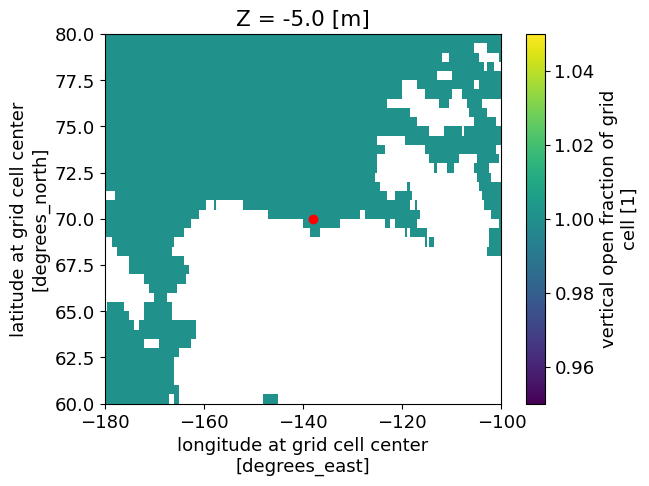

In [285]:
# pick a point near Mackenzie outflow
ecco_grid.hFacC.isel(Z=0).sel(latitude=slice(60,80),longitude=slice(-180,-100)).plot();
plt.scatter(-138,70,color='r');

In [289]:
ecco_grid.sel(latitude=70,longitude=-138, method='nearest').area.values*4 # multiply by 4 because the runoff dataset is on 1 deg grid

4178105918.451084

^ pretty close

In [295]:
runoff_mackenzie = runoff_ds.isel(i=slice(221,223),j=160)

In [305]:
runoff_mackenzie

<xarray.DataArray (month: 12, i: 2)>
array([[  0.7497194 ,  32.348557  ],
       [  0.6650669 ,  30.039467  ],
       [  0.62128407,  27.98317   ],
       [  0.677719  ,  29.034958  ],
       [ 14.913815  , 113.47932   ],
       [ 20.006945  , 170.27995   ],
       [  9.941211  , 142.67484   ],
       [  8.968248  , 114.600105  ],
       [  7.2283373 ,  94.14726   ],
       [  3.1299765 ,  75.08298   ],
       [  1.3146517 ,  39.329678  ],
       [  0.91078377,  30.280605  ]], dtype='>f4')
Coordinates:
  * month    (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
    j        int64 160
  * i        (i) int64 221 222
Attributes:
    description:  Runoff
    units:        m/s

In [307]:
# m/s * m2
runoff_m3pers = runoff_mackenzie * grid_area_m2.values[0]

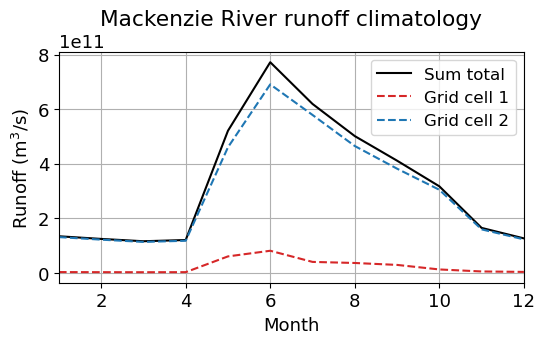

In [309]:
plt.rcParams['font.size'] = 13
# select two grid cells dedicated to Mackenzie River outflow
runoff_m3pers.sum(dim='i').plot(color='k',figsize=[6,3],label='Sum total'); # we can sum them because they are the same area grid cells
runoff_m3pers.isel(i=0).plot(color='tab:red',linestyle='dashed',label='Grid cell 1')
runoff_m3pers.isel(i=1).plot(color='tab:blue',linestyle='dashed',label='Grid cell 2')
plt.title('Mackenzie River runoff climatology')
plt.legend(fontsize=12)
# plt.ylim(0,200)
plt.xlim(1,12)
plt.grid()
plt.ylabel(r'Runoff (m$^3$/s)')
plt.xlabel('Month');